In [21]:
# library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping
sns.set_style("darkgrid")
plt.style.use("dark_background") 

In [22]:
# check the gpu
devices = tf.config.list_physical_devices()
print("Devices found:", devices)

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print("Success! GPU is active.")
    # This line tells TF to use the GPU specifically
    tf.config.set_visible_devices(gpu_devices[0], 'GPU')
else:
    print("GPU still not found. You might be running an Intel version of Python.")
import pandas as pd

Devices found: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Success! GPU is active.


In [23]:
f = pd.read_parquet('/Users/faizshaikh/Documents/MATLAB/transmission_system/Training_Dataset.parquet')
print(f.head())

                                       TransientData  FaultID  Interface
0  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...  Fault01       30.0
1  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...  Fault01       60.0
2  [{'Va': 1.08326546064588e-17, 'Vb': -4.5008479...  Fault01       90.0
3  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...  Fault01       30.0
4  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...  Fault01       60.0


In [24]:
# update the fault IDs to class
mapping = {
    'LG': ['Fault01', 'Fault02', 'Fault03', 'Fault12', 'Fault13', 'Fault14', 
           'Fault23', 'Fault24', 'Fault25', 'Fault34', 'Fault35', 'Fault36'],
    'LL': ['Fault04', 'Fault05', 'Fault06', 'Fault15', 'Fault16', 'Fault17', 
           'Fault26', 'Fault27', 'Fault28', 'Fault37', 'Fault38', 'Fault39'],
    'LLG': ['Fault07', 'Fault08', 'Fault09', 'Fault18', 'Fault19', 'Fault20', 
            'Fault29', 'Fault30', 'Fault31', 'Fault40', 'Fault41', 'Fault42'],
    'LLL/LLLG': ['Fault10', 'Fault21', 'Fault32', 'Fault43', 'Fault11', 'Fault22', 'Fault33', 'Fault44'],
}

reverse_map = {fault: label for label, faults in mapping.items() for fault in faults}

f.loc[0:1187, 'FaultID'] = f.loc[0:1187, 'FaultID'].map(reverse_map)


print(f.head())


                                       TransientData FaultID  Interface
0  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...      LG       30.0
1  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...      LG       60.0
2  [{'Va': 1.08326546064588e-17, 'Vb': -4.5008479...      LG       90.0
3  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...      LG       30.0
4  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...      LG       60.0


In [25]:
# update rows 298 to 594
f.loc[297:593, 'Interface'] += 100

# update rows 595 to 891
f.loc[594:890, 'Interface'] += 200

# update rows 892 to 1188
f.loc[891:1187, 'Interface'] += 300

f = f.rename(columns={'FaultID': 'Fault Type', 'Interface': 'Distance'})

print(f.head())

                                       TransientData Fault Type  Distance
0  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...         LG      30.0
1  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...         LG      60.0
2  [{'Va': 1.08326546064588e-17, 'Vb': -4.5008479...         LG      90.0
3  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...         LG      30.0
4  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...         LG      60.0


In [26]:
f["Fault Type"].value_counts()

Fault Type
NoFault     594
LG          324
LL          324
LLG         324
LLL/LLLG    216
Name: count, dtype: int64

<Axes: xlabel='Fault Type', ylabel='count'>

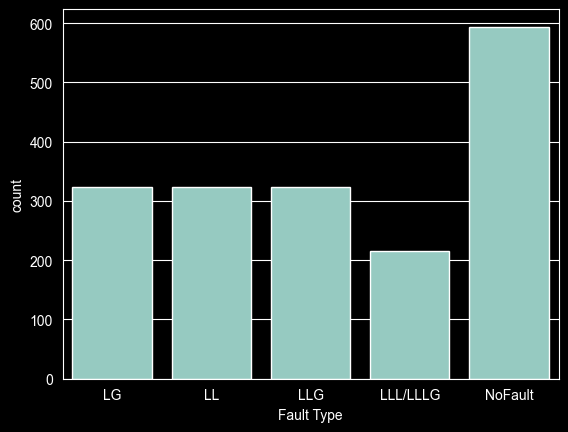

In [27]:
sns.countplot(x=f['Fault Type'])

In [28]:
le = LabelEncoder()
f['Fault Type'] = le.fit_transform(f['Fault Type'])

print(f.head())

                                       TransientData  Fault Type  Distance
0  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...           0      30.0
1  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...           0      60.0
2  [{'Va': 1.08326546064588e-17, 'Vb': -4.5008479...           0      90.0
3  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...           0      30.0
4  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...           0      60.0


In [29]:
# This iterates through every simulation, expands the dictionaries, and stacks them
#X = np.array([pd.DataFrame.from_records(sim).values for sim in f['TransientData']])
X = np.array([
    pd.DataFrame([
        dict(list(record.items())[-4:]) for record in sim
    ]).values 
    for sim in f['TransientData']
])

#threshold = 1e-5
#X[np.abs(X) < threshold] = 1e-5

#X[ :, :21, 1:4] = 1e-5

X = X[:, 20:, :]


features = ['Fault Type', 'Distance']
y = f[features].to_numpy()

print({X.shape}) 
print({y.shape})

{(1782, 301, 4)}
{(1782, 2)}


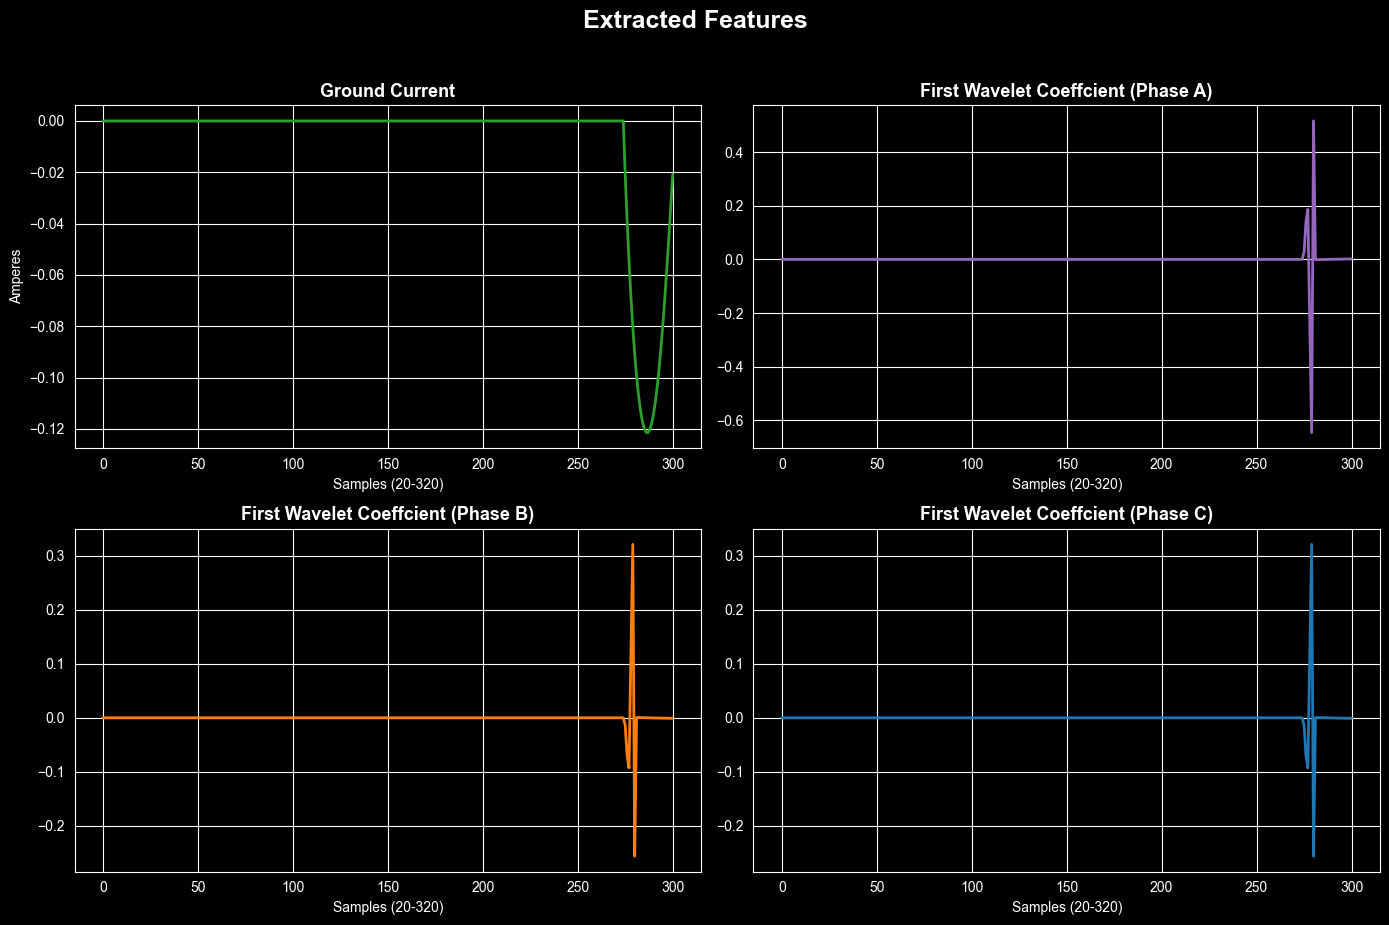

In [30]:
n = 600

Ig = X[n, :, 0] 
D1a = X[n, :, 1]
D1b = X[n, :, 2]
D1c = X[n, :, 3]

fig = plt.figure(figsize=(14, 10))
plt.suptitle("Extracted Features", fontsize=18, fontweight='bold', y=0.95)

def style_plot(title, ylabel):
    plt.title(title, fontsize=13, fontweight='semibold')
    plt.xlabel("Samples (20-320)", fontsize=10)
    plt.ylabel(ylabel, fontsize=10)

plt.subplot(2, 2, 1)
plt.plot(Ig, color='#2ca02c', linewidth=2)
style_plot("Ground Current", "Amperes")

plt.subplot(2, 2, 2)
plt.plot(D1a, color='#9467bd', linewidth=2)
style_plot("First Wavelet Coeffcient (Phase A)", "")

plt.subplot(2, 2, 3)
plt.plot(D1b, color='#ff7f0e', linewidth=2)
style_plot("First Wavelet Coeffcient (Phase B)", "")

plt.subplot(2, 2, 4)
plt.plot(D1c, color='#1f77b4', linewidth=2)
style_plot("First Wavelet Coeffcient (Phase C)", "")

plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
plt.show()


In [31]:
# 1. Group Scale (Columns 1 to 3) - Remains 3D
Xw = X[:, :, 1:4]
Xw_min, Xw_max = np.min(Xw), np.max(Xw)
Xw_scaled = ((Xw - Xw_min) / (Xw_max - Xw_min))

# 2. Single Column Scale (Column 0) - Use 0:1 to keep it 3D!
Xg = X[:, :, 0:1] # Shape is (Samples, 320, 1)
Xg_reshaped = Xg.reshape(-1, 1)

scaler_X = MinMaxScaler()
Xg_scaled_2d = scaler_X.fit_transform(Xg_reshaped)

# Reshape back to the original 3D sub-shape
Xg_scaled = Xg_scaled_2d.reshape(Xg.shape) 

X[:, :, 1:4] = Xw
X[:, :, 0:1] = Xg_scaled

# 3. Concatenate - Both are now 3D
#X_final = np.concatenate((Xg_scaled, Xw_scaled), axis=2)
#print(X_final.shape)

# splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5)

# 1. Create the scaler

# 2. Flatten 3D to 2D to "teach" the scaler the Min/Max of each of the 6 sensors
# We reshape to (-1, 4) which means "all time steps and samples combined"
#X_train_reshaped = X_train.reshape(-1, 4)
#scaler_X.fit(X_train_reshaped)


# 3. Transform Train, Val, and Test
#X_train_scaled = scaler_X.transform(X_train_reshaped).reshape(X_train.shape)
#X_val_scaled = scaler_X.transform(X_val.reshape(-1, 4)).reshape(X_val.shape)
#X_test_scaled = scaler_X.transform(X_test.reshape(-1, 4)).reshape(X_test.shape)

scaler_y = MinMaxScaler()

y_train_class = y_train[:, 0]
y_train_dist = y_train[:, 1].reshape(-1, 1)
scaler_y.fit(y_train_dist)
y_train_dist_scaled = scaler_y.transform(y_train_dist)

y_test_class = y_test[:, 0]
y_test_dist = y_test[:, 1].reshape(-1, 1)
y_test_dist_scaled = scaler_y.transform(y_test_dist)

y_val_class = y_val[:, 0]
y_val_dist = y_val[:, 1].reshape(-1, 1)
y_val_dist_scaled = scaler_y.transform(y_val_dist)

# only one-hot encode the CLASS
y_test_cat = tf.keras.utils.to_categorical(y_test_class)
y_val_cat = tf.keras.utils.to_categorical(y_val_class)
y_train_cat = tf.keras.utils.to_categorical(y_train_class)

In [ ]:
inputs = tf.keras.layers.Input(shape=(301, 4))

# Noise for robustness
x = tf.keras.layers.GaussianDropout(0.1)(inputs)

# Block 1: Capture fine ripples
x = tf.keras.layers.Conv1D(32, 3, padding='same')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling1D(2)(x)

# Block 2: Dilated Conv to see the "context" of the fault
x = tf.keras.layers.Conv1D(64, 3, padding='same', dilation_rate=2)(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(2)(x)

# Block 3: Deeper features
x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.SpatialDropout1D(0.2)(x)

# --- Branch 1: Classification ---
type_x = tf.keras.layers.GlobalAveragePooling1D()(x) # Averages the signal signature
type_x = tf.keras.layers.Dense(64, activation='relu')(type_x)
type_output = tf.keras.layers.Dense(5, activation='softmax', name='type')(type_x)

# --- Branch 2: Distance ---
dist_x = tf.keras.layers.GlobalMaxPooling1D()(x) # Focuses on the strongest transient peak
dist_x = tf.keras.layers.Dense(64, activation='leaky_relu')(dist_x)
dist_output = tf.keras.layers.Dense(1, activation='linear', name='distance')(dist_x)

# Define the model with 1 input and 2 outputs
model = tf.keras.Model(inputs=inputs, outputs=[type_output, dist_output])

# Compile with specialized losses for each task
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0), 
    loss_weights={'type': 1.0, 'distance': 10.0},
    loss={'type': 'categorical_crossentropy', 'distance': 'mse'},
    metrics={'type': 'accuracy', 'distance': 'mae'},

)

In [33]:
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 301, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_dropout_1  │ (None, 301, 4)    │          0 │ input_layer_1[0]… │
│ (GaussianDropout)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 301, 32)   │        416 │ gaussian_dropout… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 301, 32)   │        128 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 150, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 150, 64)   │      6,208 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 64)   │        256 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 75, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 75, 128)   │     24,704 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 75, 128)   │          0 │ conv1d_7[0][0]    │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ spatial_dropout1… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ spatial_dropout1… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type (Dense)        │ (None, 5)         │        325 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distance (Dense)    │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,614 (189.90 KB)

 Trainable params: 48,422 (189.15 KB)

 Non-trainable params: 192 (768.00 B)

None


In [34]:
model.compile(
    optimizer='adam', 
    loss={'type': 'categorical_crossentropy', 'distance': 'mse'},
    metrics={'type': 'accuracy', 'distance': 'mae'}
)

# 1. Create a weight array of 1.0s for all samples
#sample_weights = np.ones(shape=(len(y_train_class),))
#distance_weights = np.ones(shape=(len(y_train_class),))

# 2. Assign higher weights (e.g., 5.0) specifically to LLL and LLLG
# Assuming y_train_class contains the integer labels (0-5)
#sample_weights[y_train_class == 3] = 5.0
#sample_weights[y_train_class == 4] = 5.0

#es = EarlyStopping(monitor='val_loss', patience=15, verbose=1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5),

# Assuming y_train_cat is (Samples, 6) and y_train_dist_scaled is (Samples, 1)
history = model.fit(
    X_train, 
    {'type': y_train_cat, 'distance': y_train_dist_scaled}, 
    epochs=100, 
    batch_size=32,
    callbacks=[reduce_lr],
    #sample_weight={'type':sample_weights, 'distance':distance_weights},
    validation_data=(X_val, {'type': y_val_cat, 'distance': y_val_dist_scaled}),
    #callbacks=[es]
)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - distance_loss: 3.2048 - distance_mae: 1.0250 - loss: 4.7801 - type_accuracy: 0.3219 - type_loss: 1.5607 - val_distance_loss: 0.1784 - val_distance_mae: 0.3152 - val_loss: 1.7490 - val_type_accuracy: 0.3632 - val_type_loss: 1.5709 - learning_rate: 0.0010
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - distance_loss: 1.3394 - distance_mae: 0.6970 - loss: 2.7517 - type_accuracy: 0.4371 - type_loss: 1.4073 - val_distance_loss: 0.1735 - val_distance_mae: 0.3184 - val_loss: 1.7531 - val_type_accuracy: 0.3587 - val_type_loss: 1.5801 - learning_rate: 0.0010
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - distance_loss: 0.5482 - distance_mae: 0.5078 - loss: 1.8720 - type_accuracy: 0.4521 - type_loss: 1.3197 - val_distance_loss: 0.1645 - val_distance_mae: 0.3139 - val_loss: 1.8287 - val_type_accuracy: 0.3587 - val_type_loss: 1.6648 - learning_rate: 0.0010
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - distance_loss: 0.451

In [35]:
# 1. Get raw predictions (Returns a list of 2 arrays)
# predictions[0] = Fault Type probabilities
# predictions[1] = Scaled Distance
predictions = model.predict(X_test)

# 2. Extract and Process Fault Types (Classification Head)
y_pred_probs = predictions[0] 
y_pred_class = np.argmax(y_pred_probs, axis=1)
# Use your categorical y_test data (index 0 to 5)
y_test_class = np.argmax(y_test_cat, axis=1) 

# 3. Extract and Process Distance (Regression Head)
y_pred_dist_scaled = predictions[1]
# Use your scaled y_test distance data
y_test_dist_scaled = y_test_dist_scaled 

# 4. Un-scale the distance back to meters
y_pred_dist_m = scaler_y.inverse_transform(y_pred_dist_scaled)
y_test_dist_m = scaler_y.inverse_transform(y_test_dist_scaled.reshape(-1, 1))

print("--- FAULT TYPE CLASSIFICATION REPORT ---")
target_names = ['LG', 'LL', 'LLG', 'LLL/LLLG', 'No Fault']
print(classification_report(y_test_class, y_pred_class, target_names=target_names))

mae_m = mean_absolute_error(y_test_dist_m, y_pred_dist_m)
r2 = r2_score(y_test_dist_m, y_pred_dist_m)

print("--- DISTANCE ESTIMATION ACCURACY ---")
print(f"Average Location Error: {mae_m:.2f}")
print(f"R2 Score (Model Fit): {r2:.4f}")

print(f"{'Actual Type':<12} | {'Pred Type':<12} | {'Actual Dist':<12} | {'Pred Dist':<12}")
print("-" * 65)
for i in range(15): # Checking the first 15 samples
    act_t = target_names[y_test_class[i]]
    pre_t = target_names[y_pred_class[i]]
    act_d = y_test_dist_m[i][0]
    pre_d = y_pred_dist_m[i][0]
    
    print(f"{act_t:<12} | {pre_t:<12} | {act_d:<10.2f} | {pre_d:<10.2f} ")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
--- FAULT TYPE CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

          LG       0.86      0.25      0.39        24
          LL       0.27      0.77      0.39        57
         LLG       0.52      0.65      0.58        40
    LLL/LLLG       0.00      0.00      0.00        33
    No Fault       0.00      0.00      0.00        69

    accuracy                           0.34       223
   macro avg       0.33      0.33      0.27       223
weighted avg       0.25      0.34      0.25       223

--- DISTANCE ESTIMATION ACCURACY ---
Average Location Error: 107.11
R2 Score (Model Fit): 0.1041
Actual Type  | Pred Type    | Actual Dist  | Pred Dist   
-----------------------------------------------------------------
No Fault     | LL           | 0.00       | 77.01      
LG           | LLG          | 260.00     | 123.51     
LLG          | LLG          | 90.00      | 117.29     
LLG          | LL           | 230.00     | 128

/Users/faizshaikh/anaconda3/envs/machine_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/faizshaikh/anaconda3/envs/machine_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/faizshaikh/anaconda3/envs/machine_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

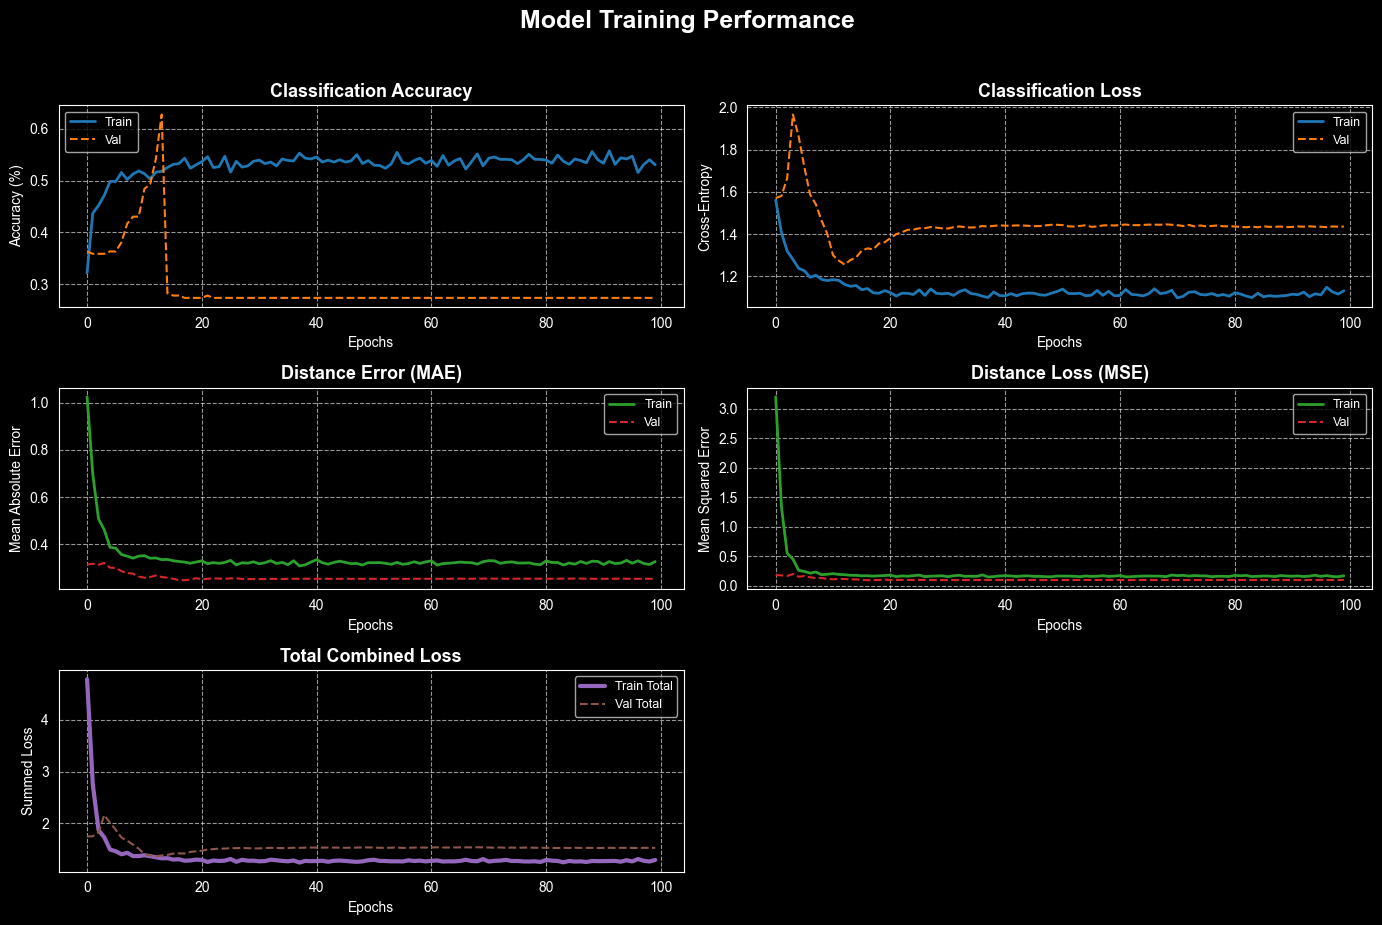

In [36]:
# 1. Increase figure size for 5 subplots
fig = plt.figure(figsize=(14, 10))
plt.suptitle("Model Training Performance", fontsize=18, fontweight='bold', y=0.95)

# Helper function to style each subplot consistently
def style_plot(title, ylabel):
    plt.title(title, fontsize=13, fontweight='semibold')
    plt.xlabel("Epochs", fontsize=10)
    plt.ylabel(ylabel, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(frameon=True, fontsize=9)

# --- 1. Type Accuracy ---
plt.subplot(3, 2, 1)
plt.plot(history.history["type_accuracy"], label='Train', color='#1f77b4', linewidth=2)
plt.plot(history.history["val_type_accuracy"], label='Val', color='#ff7f0e', linestyle='--')
style_plot("Classification Accuracy", "Accuracy (%)")

# --- 2. Type Loss ---
plt.subplot(3, 2, 2)
plt.plot(history.history["type_loss"], label='Train', color='#1f77b4', linewidth=2)
plt.plot(history.history["val_type_loss"], label='Val', color='#ff7f0e', linestyle='--')
style_plot("Classification Loss", "Cross-Entropy")

# --- 3. Distance MAE ---
plt.subplot(3, 2, 3)
plt.plot(history.history["distance_mae"], label='Train', color='#2ca02c', linewidth=2)
plt.plot(history.history["val_distance_mae"], label='Val', color='#d62728', linestyle='--')
style_plot("Distance Error (MAE)", "Mean Absolute Error")


# --- 4. Distance Loss (MSE) ---
plt.subplot(3, 2, 4)
plt.plot(history.history["distance_loss"], label='Train', color='#2ca02c', linewidth=2)
plt.plot(history.history["val_distance_loss"], label='Val', color='#d62728', linestyle='--')
style_plot("Distance Loss (MSE)", "Mean Squared Error")

# --- 5. Total Combined Loss ---
plt.subplot(3, 2, 5)
plt.plot(history.history["loss"], label='Train Total', color='#9467bd', linewidth=3)
plt.plot(history.history["val_loss"], label='Val Total', color='#8c564b', linestyle='--')
style_plot("Total Combined Loss", "Summed Loss")

# 2. Prevent overlapping labels
plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
plt.show()

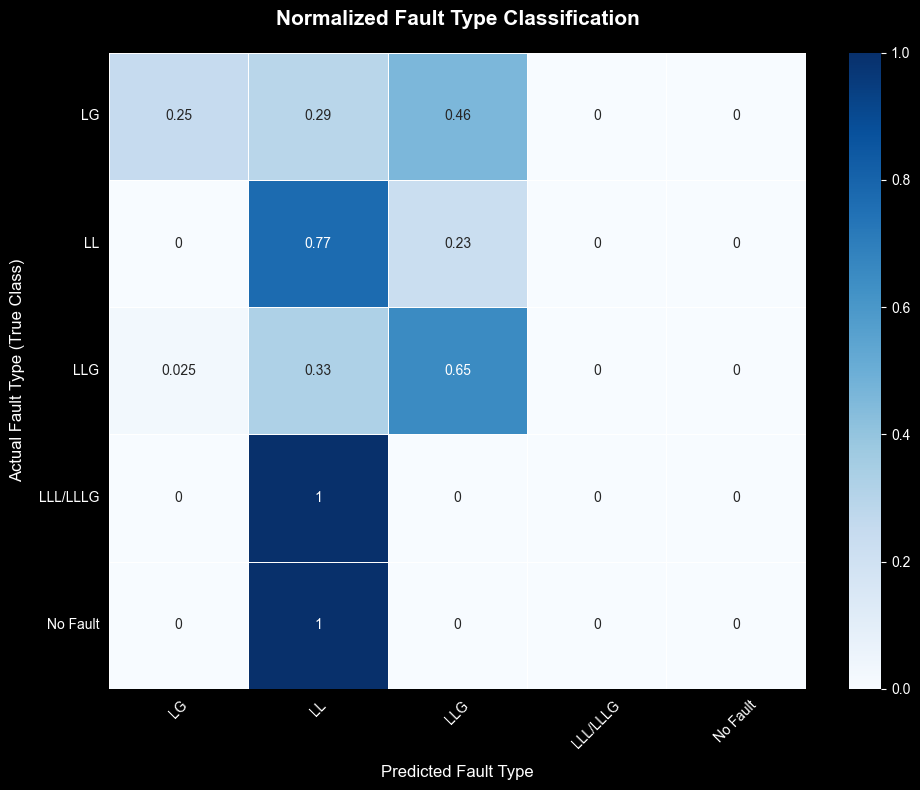

In [37]:
# 1. Define labels
target_names = ['LG', 'LL', 'LLG', 'LLL/LLLG', 'No Fault']

# 2. Generate the raw matrix
cf_matrix = confusion_matrix(np.argmax(y_test_cat, axis=1), np.argmax(y_pred_probs, axis=1))

# Divide each row by its sum to get percentages (0.0 to 1.0)
# We use np.newaxis to ensure the division happens row-by-row
cf_normalized = cf_matrix.astype('float') / cf_matrix.sum(axis=1)[:, np.newaxis]

# 3. Plotting
plt.figure(figsize=(10, 8))

# We use cf_normalized for the colors, but "fmt='.2%'" to show percentages
sns.heatmap(cf_normalized, 
            annot=True,  
            cmap="Blues", 
            xticklabels=target_names, 
            yticklabels=target_names,
            linewidths=.5)

plt.title("Normalized Fault Type Classification", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Predicted Fault Type", fontsize=12, labelpad=10)
plt.ylabel("Actual Fault Type (True Class)", fontsize=12, labelpad=10)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

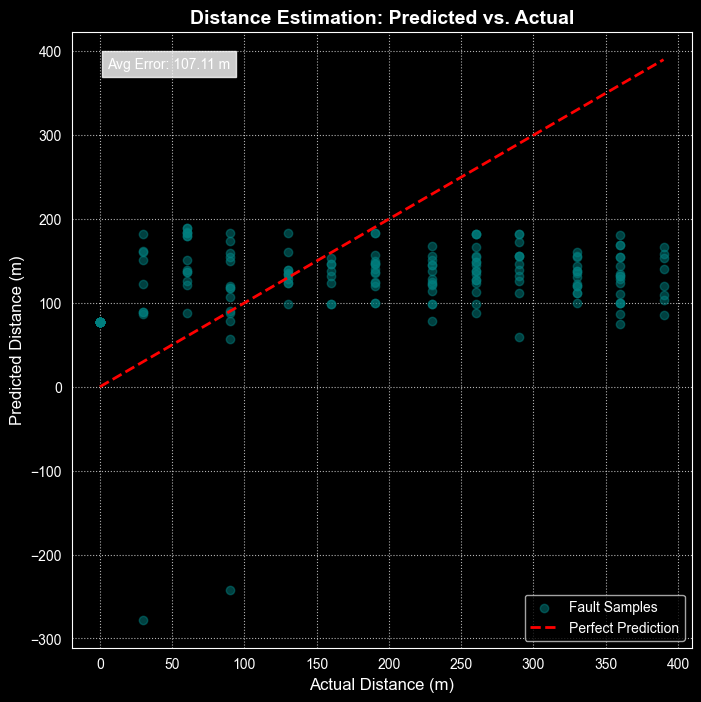

In [38]:
# 1. Create the plot
plt.figure(figsize=(8, 8))

# 2. Scatter plot of Actual vs Predicted
plt.scatter(y_test_dist_m, y_pred_dist_m, alpha=0.5, color='teal', label='Fault Samples')

# 3. The "Perfect Prediction" Line
# We draw a line from the min distance to the max distance
limits = [np.min(y_test_dist_m), np.max(y_test_dist_m)]
plt.plot(limits, limits, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title("Distance Estimation: Predicted vs. Actual", fontsize=14, fontweight='bold')
plt.xlabel("Actual Distance (m)", fontsize=12)
plt.ylabel("Predicted Distance (m)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# 4. Add a text box with the MAE
mae_m = mean_absolute_error(y_test_dist_m, y_pred_dist_m)
plt.text(limits[0]+5, limits[1]-10, f'Avg Error: {mae_m:.2f} m', bbox=dict(facecolor='white', alpha=0.8))

plt.show()

In [39]:
# The "Gain" you need is (max - min)
gain_y = scaler_y.data_max_[0] - scaler_y.data_min_[0]

# The "Offset" is the minimum value
offset_y = scaler_y.data_min_[0]

print(f"Gain[distance]: {gain_y}")
print(f"Offset[distance]: {offset_y}")

Gain[distance]: 390.0
Offset[distance]: 0.0


In [40]:
# save the model
model.save("CNNmodel.keras")
